In [37]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(knitr, tidyverse, ggplot2, dplyr, lubridate, stringr, readxl, data.table, gdata, scales, broom, stargazer, rdrobust)
source("../data-build/functions.R")
source("../data-build/rating_variables.R")

ma_final <- read_csv("../../hwk3/data/output/final-ma-data.csv")

Rows: 440877 Columns: 110
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (94): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Question 1

In [2]:
summary_table <- ma_final %>%
    filter(!is.na(Star_Rating)) %>%
  mutate(plan_market_share = avg_enrollment / avg_eligibles) %>%
  group_by(year) %>%
  summarize(
    `Mean Star Rating` = mean(Star_Rating, na.rm = TRUE),
    `Mean Enrollment` = mean(avg_enrollment, na.rm = TRUE),
    `Mean Market Share` = mean(plan_market_share, na.rm = TRUE),
    `Plan Count` = n()
  )

summary_table

year,Mean Star Rating,Mean Enrollment,Mean Market Share,Plan Count
<dbl>,<dbl>,<dbl>,<dbl>,<int>
2010,2.969968,345.9702,0.01245348,60519
2011,3.255317,388.3079,0.01506869,55249
2012,3.359556,410.6486,0.01656644,58169
2013,3.548875,406.7334,0.01631573,64174
2014,3.806049,451.1140,0.01785064,58636
2015,3.961542,482.5712,0.01930427,60819


# Question 2

In [3]:
# Create table for unrated plans
summary_no_stars <- ma_final %>%
 filter(is.na(Star_Rating)) %>%
  mutate(plan_market_share = avg_enrollment / avg_eligibles) %>%
  group_by(year) %>%
  summarize(
    `Mean Enrollment` = mean(avg_enrollment, na.rm = TRUE),
    `Mean Market Share` = mean(plan_market_share, na.rm = TRUE),
    `Count of Plans` = n()
  )

summary_no_stars

year,Mean Enrollment,Mean Market Share,Count of Plans
<dbl>,<dbl>,<dbl>,<int>
2010,107.2581,0.009183432,49431
2011,167.8986,0.013221663,12754
2012,172.7340,0.011860378,9077
2013,213.5044,0.017416414,3661
2014,257.5963,0.015849555,3708
2015,314.2103,0.008666974,4680


# Question 3

Warning message:
“Removed 63188 rows containing non-finite values (`stat_count()`).”


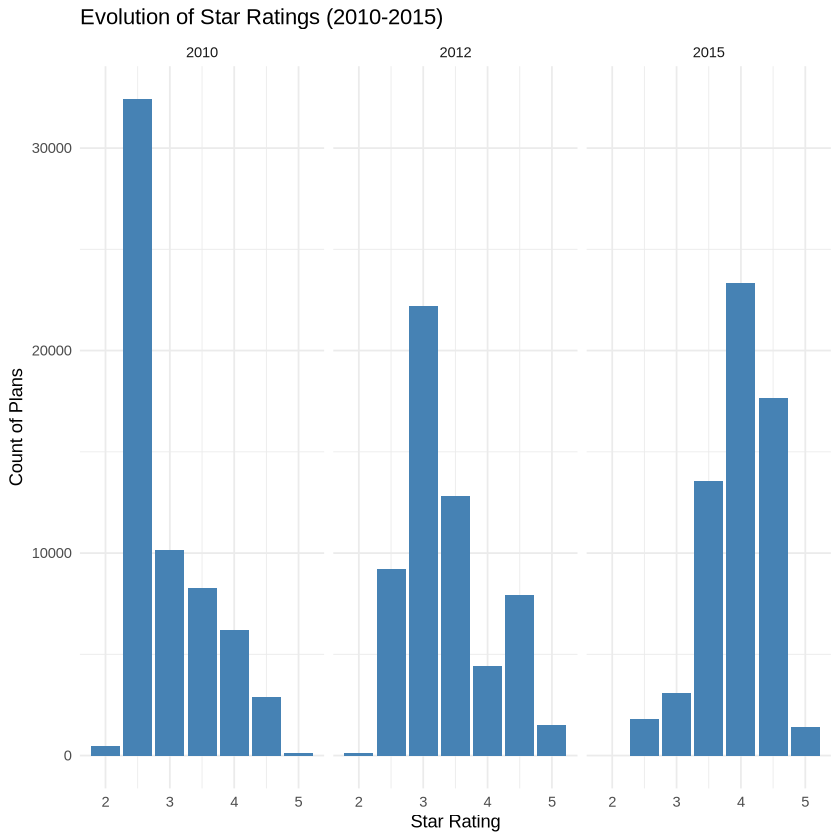

In [11]:
ma_final %>%
  filter(year %in% c(2010, 2012, 2015)) %>%
  ggplot(aes(x = Star_Rating)) +
  geom_bar(fill = "steelblue") +
  facet_wrap(~year, nrow = 1) + 
  labs(
    title = "Evolution of Star Ratings (2010-2015)",
    x = "Star Rating",
    y = "Count of Plans"
  ) +
  theme_minimal()

Between 2010 and 2015, the distribution of MA star ratings saw a significant rightward shift. In 2010, the market was dominated by lower-rated plans, with 2.5 stars being the most frequent at 30,000+ occurrences. By 2012, the distribution began to center with 3.0 being the most common rating. 2015 shows the distribution had transitioned to a high-quality skew where 4.0 plans were the highest count of plans, while the count of 2.5 star plans dropped to below 5,000.

# Question 4

In [38]:
reg_data <- ma_final %>%
  group_by(year, contractid, planid) %>%
  summarize(
    star_rating = mean(Star_Rating, na.rm = TRUE),
    plan_enrollment = sum(avg_enrollment, na.rm = TRUE),
    total_market_enrollment = sum(avg_enrolled, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(market_share = plan_enrollment / total_market_enrollment) %>%
  filter(!is.na(star_rating), !is.na(market_share)) %>%
# Create star rating factor (excluding 2.5 or below)
  mutate(star_cat = case_when(
    star_rating <= 2.5 ~ "stars_2.5_or_below",
    star_rating == 3.0 ~ "stars_3.0",
    star_rating == 3.5 ~ "stars_3.5",
    star_rating == 4.0 ~ "stars_4.0",
    star_rating >= 4.5 ~ "stars_4.5_plus"
  )) %>%
  mutate(star_cat = factor(star_cat, levels = c("stars_2.5_or_below", "stars_3.0", "stars_3.5", "stars_4.0", "stars_4.5_plus")))

# Run regression for each year
models_list <- map(2010:2015, ~ lm(market_share ~ star_cat, data = filter(reg_data, year == .x)))

stargazer(models_list, 
          type = "text",
          column.labels = as.character(2010:2015),
          dep.var.labels = "Market Share",
          covariate.labels = c("3 Stars", "3.5 Stars", "4 Stars", "4.5+ Stars"),
          omit.stat = c("f", "ser"),
          title = "OLS Regression of Market Share on Star Ratings (2010-2015)",
          align = TRUE)


OLS Regression of Market Share on Star Ratings (2010-2015)
                             Dependent variable:                 
             ----------------------------------------------------
                                 Market Share                    
               2010     2011     2012     2013    2014     2015  
               (1)      (2)      (3)      (4)      (5)     (6)   
-----------------------------------------------------------------
3 Stars       0.007*   0.010*   0.0001  0.016***  0.006   -0.005 
             (0.004)  (0.005)  (0.005)  (0.005)  (0.011) (0.007) 
                                                                 
3.5 Stars    0.013***  0.009    -0.003  0.011**   0.006   0.002  
             (0.004)  (0.005)  (0.005)  (0.005)  (0.011) (0.007) 
                                                                 
4 Stars      0.014***  0.006    -0.008   0.005    0.003   -0.006 
             (0.004)  (0.006)  (0.005)  (0.005)  (0.011) (0.007) 
                

# Question 5

In [19]:
rd_table_data <- ma_2010 %>%
  mutate(
    raw_score = rowMeans(
      across(any_of(rating.vars.2010) & where(is.numeric)), 
      na.rm = TRUE
    )
  ) %>%
  filter(!is.na(raw_score)) %>%
  mutate(
    rounded_up = case_when(
      raw_score >= 2.75 & raw_score < 3.00 & Star_Rating == 3.0 ~ "3.0 Stars",
      raw_score >= 3.25 & raw_score < 3.50 & Star_Rating == 3.5 ~ "3.5 Stars",
      raw_score >= 3.75 & raw_score < 4.00 & Star_Rating == 4.0 ~ "4.0 Stars",
      raw_score >= 4.25 & raw_score < 4.50 & Star_Rating == 4.5 ~ "4.5 Stars",
      raw_score >= 4.75 & raw_score < 5.00 & Star_Rating == 5.0 ~ "5.0 Stars",
      TRUE ~ NA_character_
    )
  )

rounding_summary <- rd_table_data %>%
  filter(!is.na(rounded_up)) %>%
  count(rounded_up, name = "Number of Plans Rounded Up") %>%
  rename(`Star Rating` = rounded_up)

rounding_summary

Star Rating,Number of Plans Rounded Up
<chr>,<int>
3.0 Stars,3808
3.5 Stars,4524
4.0 Stars,4077
4.5 Stars,773
5.0 Stars,30


# Question 6

In [36]:
# Calculate raw scores
rd_table_data <- ma_2010 %>%
  mutate(
    raw_score = rowMeans(
      select(., any_of(rating.vars.2010)) %>% select(where(is.numeric)), 
      na.rm = TRUE
    )
  ) %>%
  filter(!is.na(raw_score))

# Aggregate to plan-year level
rd_enrollment_data <- rd_table_data %>%
  group_by(contractid, planid) %>%
  summarize(
    raw_score = mean(raw_score, na.rm = TRUE),
    total_enrollment = sum(avg_enrollment, na.rm = TRUE),
    .groups = "drop"
  )

# RD estimation function (bandwidth = 0.125)
estimate_rd <- function(data, threshold, bw = 0.125) {
  data %>%
    mutate(dist = raw_score - threshold) %>%
    filter(abs(dist) <= bw) %>%
    mutate(treated = ifelse(dist >= 0, 1, 0)) %>%
    lm(total_enrollment ~ treated + dist, data = .)
}

# Run regressions for the rounding up thresholds 
model_30 <- estimate_rd(rd_enrollment_data, 2.75)
model_35 <- estimate_rd(rd_enrollment_data, 3.25)

# Summary table using stargazer
stargazer(model_30, model_35,
          type = "text",
          column.labels = c("3.0 vs 2.5", "3.5 vs 3.0"),
          dep.var.labels = "Total Enrollments",
          covariate.labels = c("Treatment (Higher Star Rating)", "Running Variable (Distance)"),
          title = "RD Estimates using MA 2010 Data",
          omit.stat = c("f", "ser"))


RD Estimates using MA 2010 Data
                                   Dependent variable:     
                               ----------------------------
                                    Total Enrollments      
                                 3.0 vs 2.5    3.5 vs 3.0  
                                    (1)            (2)     
-----------------------------------------------------------
Treatment (Higher Star Rating)   -2,094.538     -269.304   
                                (3,193.770)    (2,046.203) 
                                                           
Running Variable (Distance)      1,357.114     -5,820.447  
                                (19,511.910)  (11,640.150) 
                                                           
Constant                        5,449.075***  3,799.438*** 
                                (1,790.259)    (1,148.518) 
                                                           
-----------------------------------------------------------
Observa

# Question 7

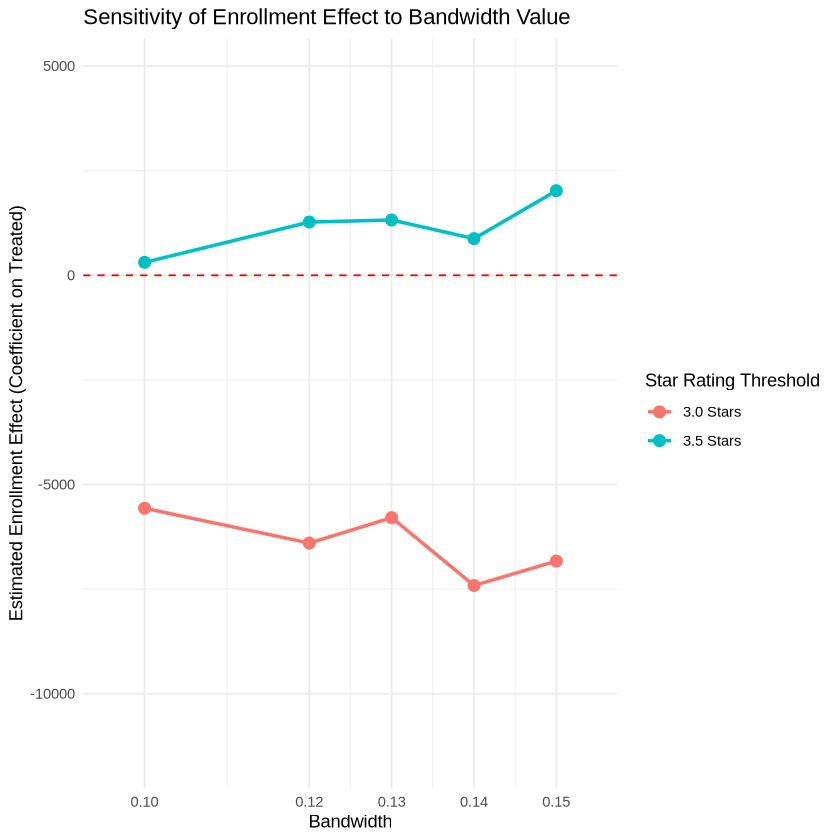

In [35]:
# Define parameters and bandwidths for analysis
thresholds <- c("3.0 Stars" = 2.75, "3.5 Stars" = 3.25)
bandwidths <- c(0.1, 0.12, 0.13, 0.14, 0.15)

# Create a function to run model and extract estimate
run_sensitivity <- function(thresh_val, thresh_label, bw) {
  model_data <- rd_enrollment_data %>%
    mutate(dist = raw_score - thresh_val) %>%
    filter(abs(dist) <= bw) %>%
    mutate(treated = ifelse(dist >= 0, 1, 0))
  
  fit <- lm(total_enrollment ~ treated + dist, data = model_data)
  
  # Data frame with estimate and standard error
  broom::tidy(fit, conf.int = TRUE) %>%
    filter(term == "treated") %>%
    mutate(bandwidth = bw, threshold = thresh_label)
}

# Run the model across all combos
sensitivity_results <- map2_dfr(
  rep(thresholds, each = length(bandwidths)),
  rep(names(thresholds), each = length(bandwidths)),
  ~run_sensitivity(.x, .y, bandwidths[match(.y, names(thresholds)) + (match(.x, thresholds) - 1) * 0])
)

sensitivity_results <- expand.grid(thresh_name = names(thresholds), bw = bandwidths) %>%
  rowwise() %>%
  do(run_sensitivity(thresholds[[.$thresh_name]], .$thresh_name, .$bw))


# Create graph
ggplot(sensitivity_results, aes(x = bandwidth, y = estimate, color = threshold)) +
    geom_line(size = 1) +
    geom_point(size = 3) +
    geom_errorbar(aes(ymin = conf.low, ymax = conf.high), linewidth = 0.005) +
    scale_x_continuous(breaks = bandwidths) +
  theme_minimal() +
  labs(
    title = "Sensitivity of Enrollment Effect to Bandwidth Value",
    x = "Bandwidth",
    y = "Estimated Enrollment Effect (Coefficient on Treated)",
    color = "Star Rating Threshold"
  ) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red")

This bandwidth sensitivity analysis shows that RD estimates are robust to the choice of bandwidth. Regardless of window size (0.1 to 0.15), the estimated effect of a star rating increase remains statistically insignificant.

# Question 8

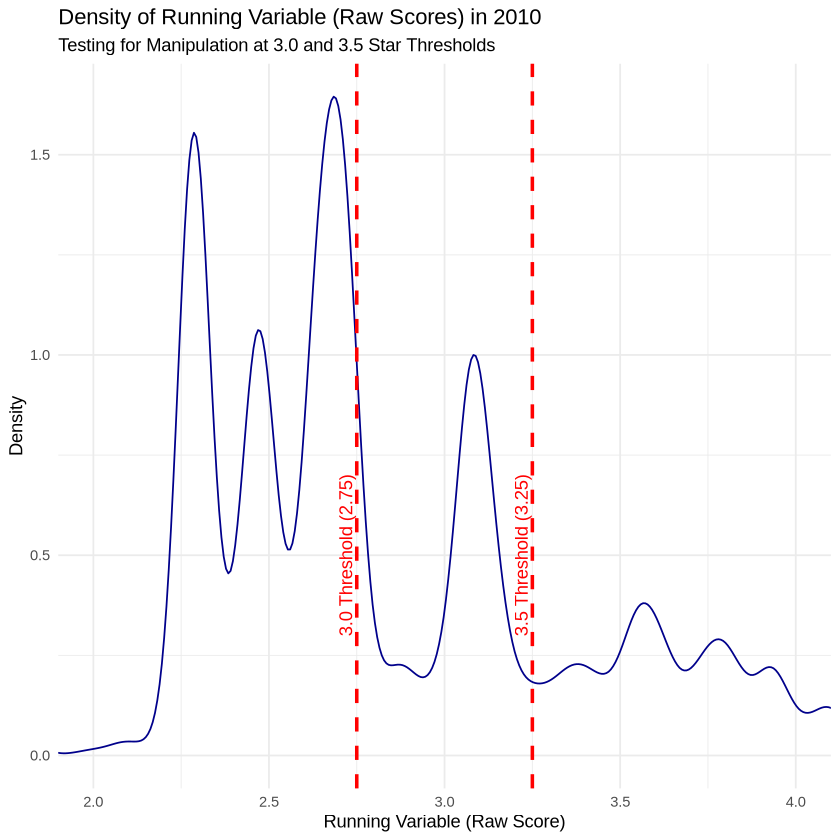

In [30]:
# Define the relevant thresholds (rounding up for 3.0 and 3.5 stars)
thresholds <- c(2.75, 3.25)

# Create the combined density plot
ggplot(rd_table_data, aes(x = raw_score)) +
  geom_density( alpha = 0.3, color = "darkblue") +
  
  # Add threshold lines
  geom_vline(xintercept = thresholds, 
             linetype = "dashed", 
             color = "red", 
             linewidth = 1) +
  
  # Add labels
  annotate("text", x = 2.70, y = 0.5, label = "3.0 Threshold (2.75)", 
           angle = 90, color = "red", vjust = 1) +
  annotate("text", x = 3.20, y = 0.5, label = "3.5 Threshold (3.25)", 
           angle = 90, color = "red", vjust = 1) +
  
  theme_minimal() +
  labs(
    title = "Density of Running Variable (Raw Scores) in 2010",
    subtitle = "Testing for Manipulation at 3.0 and 3.5 Star Thresholds",
    x = "Running Variable (Raw Score)",
    y = "Density"
  ) +

  coord_cartesian(xlim = c(2.0, 4.0))

The density plot shows a continuous distribution across the 2.75 and 3.25 thresholds (at which scores are rounded up to 3 and 3.5, respectively). There is no bunching or a discontinuous jump in the density of plans immediately following the rounding cutoffs. This supports the earlier findings that contracts did not strategically manipulate quality metrics to cross the thresholds in 2010.

# Question 9

In [33]:
balance_data <- ma_2010 %>%
  mutate(
    raw_score = rowMeans(select(., any_of(rating.vars.2010)) %>% select(where(is.numeric)), na.rm = TRUE),
    is_hmo = ifelse(grepl("HMO", plan_type, ignore.case = TRUE), 1, 0),
    has_partd = ifelse(partd == "Yes", 1, 0)
  ) %>%
  filter(!is.na(raw_score))

# RD Balance Test at 3.0 stars (threshold 2.75)
hmo_30 <- rdrobust(y = balance_data$is_hmo, x = balance_data$raw_score, c = 2.75, h = 0.125)
partd_30 <- rdrobust(y = balance_data$has_partd, x = balance_data$raw_score, c = 2.75, h = 0.125)

# RD Balance Test at 3.5 stars (threshold 3.25)
hmo_35 <- rdrobust(y = balance_data$is_hmo, x = balance_data$raw_score, c = 3.25, h = 0.125)
partd_35 <- rdrobust(y = balance_data$has_partd, x = balance_data$raw_score, c = 3.25, h = 0.125)

In [34]:
# Summary table of p-values for 3.0 and 3.5 thresholds
results_table <- data.frame(
  Characteristic = c("HMO Status", "Part D Status"),
  `P-Value at 3.0 Stars (2.75)` = c(hmo_30$pv[1], partd_30$pv[1]),
  `P-Value at 3.5 Stars (3.25)` = c(hmo_35$pv[1], partd_35$pv[1]),
  check.names = FALSE
)

results_table

Characteristic,P-Value at 3.0 Stars (2.75),P-Value at 3.5 Stars (3.25)
<chr>,<dbl>,<dbl>
HMO Status,0.000000e+00,0.000000e+00
Part D Status,1.506508e-252,9.266828e-16


# Question 10

Looking at the results of analyzing 2010 MA data in questions 5-9, we can conclude that increasing star rating had no statistically significant effect on plan enrollment. 

Question 6: We see that while we estimate a negative point estimate for both thresholds, neither is statistically significant. This suggests that in 2010, the enrollment effects at the 3.0 and 3.5 thresholds were statistically insignificant.

Question 7: Results remained relatively stable across bandwidths 0.1-0.15, proving the findings are robust.

Question 9: Both HMO status and Part D status show statistically significant discontinuities ($p < 0.01$) at the 2.75 and 3.25 thresholds. This indicates that plans above the rounding cutoffs were systematically different from those just below. Therefore, any observed effect on enrollment cannot be attributed solely to the rating, as these underlying plan characteristics likely confound the estimate.